In [1]:
import pandas as pd
import os
import numpy as np

# Multi Dataset Concatenator


Combine multiple datasets into a single one for NLP predictions.
<br><br>
 Note that this current version is specifically made for the sickness and non-sickness combination but could be repurposed for other datasets if the code was altered to fit. Must have ran "cleaning-RACode.ipynb" with both dataset to use this notebook

## Load datasets and clean to adequately concatenate

### Load Datasets

In [2]:
# Sickness Dataset
folder = r'subjects-(sickness)_FILTERS-culture_level_samples(PSF)'  
OutputDir = '../Data/' + folder
df_1 = pd.read_excel(f"{OutputDir}/_Altogether_Dataset_RACoded.xlsx",  header=[0,1], index_col=0)

# Sickness (OCMs 750-753) and nonsickness dataset (OCMs '784, '731', '732', '777', '791', '793')
folder = r'(subjects-(contracts_OR_disabilities_OR_disasters_OR_friendships_OR_gift_giving_OR_infant_feeding_OR_lineages_OR_etc'   # OCM ['586' , '684' , '688' , '731' , '732' , '756' , '767' , '777' , '791' , '792' , '793' , '431' , '572' , '594' , '613' , '624' , '675' , '853']
OutputDir = '../Data/' + folder
df_2 = pd.read_excel(f"{OutputDir}/_Altogether_Dataset_RACoded.xlsx",  header=[0,1], index_col=0)

#dataset indicators for second dataset (used to match datasets)
df_datasets = pd.read_excel(f"{OutputDir}/_Dataset_Lists.xlsx")

#Passage Text for second dataset (used to match datasets)
df_2Uncoded = pd.read_excel(f"{OutputDir}/_Altogether_Dataset_CLEANED.xlsx")

In [9]:
# DELETE dummy for abby text cleaning

# rand_pass = np.random.randint(0,len(df_2)+1,30)
# df_2.iloc[rand_pass].to_excel("../../HRAF-Misf-NaturalLanguageProcessing/Abby Text Cleaning/SampleFile.xlsx")

In [10]:
df_2Uncoded[df_2Uncoded["Passage Number"]==1016]

,Passage Number,Region,SubRegion,Culture,DocTitle,Section,Author,Page,Year,OCM,OWC,Passage
336,1016,South-America,Eastern South America,Bahia Brazilians,Culture summary: Bahia Brazilians,RELIGIOUS PRACTITIONERS,"Beierle, John",8,1999,"['754', '756', '791', '793', '794']",so11,Prior to the twentieth century Catholic priest...


In [11]:
df_2[df_2[("CULTURE","Passage Number")]==1016]

CULTURE                                                          \
    Passage Number         Region              SubRegion           Culture   
133           1016  South-America  Eastern South America  Bahia Brazilians   

                                                                 \
                              DocTitle                  Section   
133  Culture summary: Bahia Brazilians  RELIGIOUS PRACTITIONERS   

                                                                    ...  \
            Author Page  Year                                  OCM  ...   
133  Beierle, John    8  1999  ['754', '756', '791', '793', '794']  ...   

                  ACTION        \
    Priest_High_Religion Other   
133                    0     0   

                                                        \
                                           Description   
133  religious practitioner uses magic, herbs, and ...   

                                                        \
                                           Local_terms   
133  CURANDEIRO- religious practitioner used to fig...   

                                                 OTHER      CODER           \
                                        Other_Comments Run_Number Finished   
133  Passage doesn't have a misfortune event, but d...          1     True   

                     OTHER   CODER  
    Coder Other_Comments.1 Dataset  
133    KW              NaN     2.0  

[1 rows x 42 columns]

In [22]:
print("Passages in Dataset 1: ", len(df_1))
print("Passages in Dataset 2: ", len(df_2))
#Total Cultures in both datasets
print("Total Cultures in both dataset: ", len(set(df_1[("CULTURE","Culture")])|(set(df_2[("CULTURE","Culture")]))))

Passages in Dataset 1:  1977
Passages in Dataset 2:  9028
Total Cultures in both dataset:  58


### Match columns

In [13]:
# show column differences in the sickness dataset (df_1) and the combined sickness/nonsickness dataset (df_2)
set(df_1.columns).difference(set(df_2.columns))

{('CAUSE', 'Jealousy_Evil_Eye')}

In [14]:
# Alter column names to match (only done here currently as jealous_evil_eye will be converted to "other"). 
# Note that the data will be treated as the same column rather than two different columns
df_1 = df_1.rename(columns={'Jealousy_Evil_Eye':'Other'}, level=1, errors="raise")
# show again the difference (should be an empty set)
if len(set(df_1.columns).difference(set(df_2.columns))) == 0:
    print("All columns match")
else:
    print(set(df_1.columns).difference(set(df_2.columns)), "Columns unmatched")

All columns match


### Redo and Match Passage Numbers


Because the sickness dataset does not contain the same passage numbers as the combined dataset (df_2), we need to redo the passage numbers to match both datasets


#### Check For duplicates within Datasets

In [15]:
def duplicateCheck(df, runCol = ("CODER",'Run_Number'), dupCol = ('CULTURE','Passage'), keep='first'):
    # Check for Duplicate passages for first runthrough of this dataset (do not count extra runs, run number is updated later below but for here it should be 1)
    df = df.loc[df[runCol]==1]
    ds_duplicates = df.duplicated(subset=dupCol, keep=keep)
    if sum(ds_duplicates) >0:
        print('Duplicates:', sum(ds_duplicates) )
    else:
        print("No duplicate passages")
    return df[ds_duplicates]
duplicateCheck(df_2)

No duplicate passages


Empty DataFrame
Columns: [(CULTURE, Passage Number), (CULTURE, Region), (CULTURE, SubRegion), (CULTURE, Culture), (CULTURE, DocTitle), (CULTURE, Section), (CULTURE, Author), (CULTURE, Page), (CULTURE, Year), (CULTURE, OCM), (CULTURE, OWC), (CULTURE, Passage), (EVENT, No_Info), (EVENT, Illness), (EVENT, Accident), (EVENT, Other), (EVENT, Description), (EVENT, Local_Terms), (CAUSE, No_Info), (CAUSE, Just_Happens), (CAUSE, Material_Physical), (CAUSE, Spirits_Gods), (CAUSE, Witchcraft_Sorcery), (CAUSE, Rule_Violation_Taboo), (CAUSE, Other), (CAUSE, Description), (CAUSE, Local_Terms), (ACTION, No_Info), (ACTION, Physical_Material), (ACTION, Technical_Specialist), (ACTION, Divination), (ACTION, Shaman_Medium_Healer), (ACTION, Priest_High_Religion), (ACTION, Other), (ACTION, Description), (ACTION, Local_terms), (OTHER, Other_Comments), (CODER, Run_Number), (CODER, Finished), (CODER, Coder), (OTHER, Other_Comments.1), (CODER, Dataset)]
Index: []

[0 rows x 42 columns]

In [16]:
df_2[df_2[("CULTURE","Passage")].duplicated()]

Empty DataFrame
Columns: [(CULTURE, Passage Number), (CULTURE, Region), (CULTURE, SubRegion), (CULTURE, Culture), (CULTURE, DocTitle), (CULTURE, Section), (CULTURE, Author), (CULTURE, Page), (CULTURE, Year), (CULTURE, OCM), (CULTURE, OWC), (CULTURE, Passage), (EVENT, No_Info), (EVENT, Illness), (EVENT, Accident), (EVENT, Other), (EVENT, Description), (EVENT, Local_Terms), (CAUSE, No_Info), (CAUSE, Just_Happens), (CAUSE, Material_Physical), (CAUSE, Spirits_Gods), (CAUSE, Witchcraft_Sorcery), (CAUSE, Rule_Violation_Taboo), (CAUSE, Other), (CAUSE, Description), (CAUSE, Local_Terms), (ACTION, No_Info), (ACTION, Physical_Material), (ACTION, Technical_Specialist), (ACTION, Divination), (ACTION, Shaman_Medium_Healer), (ACTION, Priest_High_Religion), (ACTION, Other), (ACTION, Description), (ACTION, Local_terms), (OTHER, Other_Comments), (CODER, Run_Number), (CODER, Finished), (CODER, Coder), (OTHER, Other_Comments.1), (CODER, Dataset)]
Index: []

[0 rows x 42 columns]

### Update dataframe text to match each other's exclusions


### Update Run Number

As every dataset is coded as run 1, adding multiple datasets necessitates differentiating the runs

In [17]:
mask = df_2[("CODER",'Run_Number')]==1
df_2.loc[mask, ("CODER",'Run_Number')] = 3 # turn all 1 runs in dataset 2 into run 3
mask = df_2[("CODER",'Run_Number')]==2
df_2.loc[mask, ("CODER",'Run_Number')] = 4 # turn all 2 runs in dataset 2 into run 4 (they probably do not exist at this moment)

#### Update Passage Numbers


In [18]:
#check for incongruous passage numbers then replace them with the updated version if it is available
df_1_culture = df_1["CULTURE"].copy()
merged_df = pd.merge(df_1_culture, df_2Uncoded[['Passage Number','Passage']], on='Passage', suffixes=('_1', '_orig2'), how='left')
assert len(merged_df) == len(df_1_culture), "Error, unequal output"
incong_len = sum(merged_df["Passage Number_orig2"].isna())
print(incong_len, "passages without Passage Number")
# merged_df

120 passages without Passage Number


median 529.0
mean 620.45
min 429
max 2812


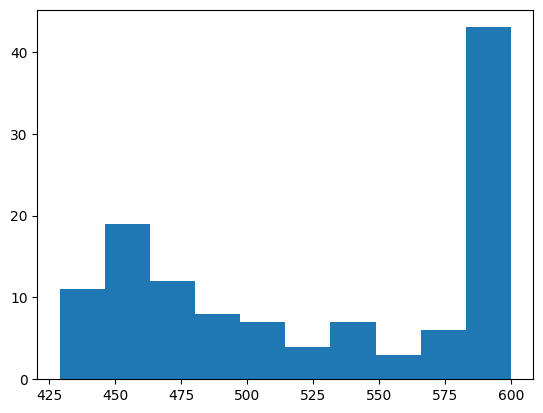

In [19]:
# (exploratory) Check passage size for invalid ID passages, if we are dealing with the sickness dataset, the "dropped" or ingorngruent pasages should be large, say 400 words or longer
passSplit = merged_df.loc[merged_df["Passage Number_orig2"].isna()]['Passage'].apply(lambda x: len(x.split()))
print("median", passSplit.median())
print('mean', passSplit.mean())
print('min', passSplit.min())
print('max', passSplit.max())
import matplotlib.pyplot as plt
import numpy as np

# x = np.random.normal(170, 10, 250)
passSplit_maxed = passSplit.apply(lambda x: min(600, x))
plt.hist(passSplit_maxed)
plt.show()

In [20]:
# Give NA Passage numbers negative numbers as to not conflict with any other passage
neg_list = list(range(-1,-sum(merged_df["Passage Number_orig2"].isna())-1, -1)) #get list of negative numbers
mask = merged_df["Passage Number_orig2"].isna()
merged_df.loc[mask,"Passage Number_orig2"] = neg_list
print("NAs left:", len(merged_df[merged_df["Passage Number_orig2"].isna()]))

NAs left: 0


In [21]:
# update df_1 Passage number
df_1[("CULTURE","Passage Number")] =  merged_df["Passage Number_orig2"]


### Concatinate both datasets

In [22]:
df_1and2 = pd.concat([df_1,df_2], ignore_index=True)
print('Data Length:', len(df_1and2))

Data Length: 11005


In [23]:
# check to make sure each unique passage number has the same passage
df_1and2_dummy = df_1and2['CULTURE'].copy()
mask1 = df_1and2_dummy.duplicated(subset = "Passage Number", keep=False)
mask2 = df_1and2_dummy[mask1].duplicated(subset = "Passage", keep=False)
# df_1and2_dummy[mask1].sort_values(by="Passage Number")
assert len(df_1and2_dummy[mask1][~mask2])==0, "ERROR, Some Passage Numbers are coded for multiple unique passages, consider investigating!"
print("All duplicate Passage Numbers point to a shared Passage (this is good)")

All duplicate Passage Numbers point to a shared Passage (this is good)


### Add Dataset Indicators

In [24]:
# Make sure this is the dataset which contains all other datasets
df_datasets
df_1and2dummy = df_1and2["CULTURE"].copy()
merged_df = pd.merge(df_1and2dummy, df_datasets[['Passage Number','Dataset']], on='Passage Number', suffixes=('_1and2', '_2dataset'), how='left')
assert sum(merged_df["Dataset"].isna()) == incong_len, "ERROR, Dataset contains more NA Dataset values than would be expected based on the incongruent count"
print(sum(merged_df["Dataset"].isna()), "Missing dataset indicators")
# print(sum(merged_df["Passage Number_orig2"].isna()), "passages without Passage Number")

120 Missing dataset indicators


In [25]:
# CHANGE New dataset indicator for passages missing one (this ideally should only be from a single dataset and corrects only the ones that were originally incongruent)
merged_df.loc[merged_df["Dataset"].isna()] = 1
print(sum(merged_df["Dataset"].isna()), "Missing dataset indicators")
# merged_df['Dataset'].value_counts(dropna=False)

0 Missing dataset indicators


In [26]:
assert len(merged_df) == len(df_1and2), "ERROR, Merged dataset is not the same length as the base dataset"
df_1and2[('CODER', "Dataset")] = merged_df["Dataset"]
df_1and2.head(3)

CULTURE                               \
  Passage Number Region   SubRegion   Culture   
0         1392.0   Asia  South Asia  Andamans   
1         1393.0   Asia  South Asia  Andamans   
2         1395.0   Asia  South Asia  Andamans   

                                                                     \
                                            DocTitle        Section   
0  Hygiene and medical practices among the Onge (...  1. Habitation   
1  Hygiene and medical practices among the Onge (...        3. Food   
2  Hygiene and medical practices among the Onge (...        3. Food   

                               \
            Author Page  Year   
0  Cipriani, Lidio  484  1961   
1  Cipriani, Lidio  487  1961   
2  Cipriani, Lidio  490  1961   

                                                      ...  \
                                                 OCM  ...   
0  ['171', '301', '727', '751', '765', '775', '777']  ...   
1  ['136', '231', '271', '312', '415', '516', '751']  ...   
2  ['114', '137', '164', '262', '273', '751', '825']  ...   

                ACTION        \
  Priest_High_Religion Other   
0                    0     1   
1                    0     0   
2                    0     0   

                                                      \
                                         Description   
0  Several customs are believed to connect with t...   
1                             No action is mentioned   
2  Certain foods, such as Pteropus (giant bat) an...   

                                                      \
                                         Local_terms   
0   ibidanghe: made from decorated human jawbone ...   
1                                                  0   
2  Pteropus: a giant bat  eaten by the Andaman Is...   

                                               OTHER      CODER           \
                                      Other_Comments Run_Number Finished   
0  General note of this spreadsheet - many of the...          1     True   
1                                                NaN          1     True   
2                                                NaN          1     True   

                   OTHER   CODER  
  Coder Other_Comments.1 Dataset  
0    YM              NaN     1.0  
1    YM              NaN     1.0  
2    YM              NaN     1.0  

[3 rows x 42 columns]

In [27]:
df_1and2["CODER"][["Run_Number", "Dataset"]].value_counts(sort=False, dropna=False)

Run_Number  Dataset
1           1.0        1926
2           1.0          51
3           1.0        4844
            2.0        4184
Name: count, dtype: int64

## Interater reliability


In [28]:
df_1and2_dummy = df_1and2.copy()
run1_pas = set(df_1and2_dummy.loc[df_1and2_dummy[("CODER","Run_Number")]==1][("CULTURE","Passage Number")])
run2_pas = set(df_1and2_dummy.loc[df_1and2_dummy[("CODER","Run_Number")]==2][("CULTURE","Passage Number")])
run3_pas = set(df_1and2_dummy.loc[df_1and2_dummy[("CODER","Run_Number")]==3][("CULTURE","Passage Number")])
print("Number of passages contained in all 3 runs:", len(run1_pas.intersection(run2_pas).intersection(run3_pas)))
run1_pas.intersection(run2_pas).intersection(run3_pas)

Number of passages contained in all 3 runs: 31


{7247.0,
 7248.0,
 7260.0,
 7261.0,
 7262.0,
 7263.0,
 7286.0,
 7287.0,
 7378.0,
 7383.0,
 7384.0,
 7386.0,
 7389.0,
 7545.0,
 7580.0,
 7599.0,
 7608.0,
 7609.0,
 7611.0,
 7614.0,
 7622.0,
 7623.0,
 7625.0,
 7627.0,
 7628.0,
 7658.0,
 7659.0,
 7660.0,
 7661.0,
 7675.0,
 7752.0}

### Get reliability of two datasets

For the sake of ease (for now) we will only assume there are two runs: 1 and 3

In [29]:
useRuns = [1,3] #change to include the runs you want to check, it is advisable just to use two
df_CatFiltered = df_1and2.copy()
df_CatFiltered = df_CatFiltered.loc[df_CatFiltered[("CODER","Run_Number")].isin(useRuns)]
df_CatFiltered = df_CatFiltered[df_CatFiltered.duplicated(subset=("CULTURE","Passage Number"), keep=False)]


#Convert the passage numbers to the index
df_CatFiltered.loc[:, "Passage Number"] = df_CatFiltered[("CULTURE", "Passage Number")]
df_CatFiltered = df_CatFiltered.drop(columns=[("CULTURE", "Passage Number")])
df_CatFiltered = df_CatFiltered.set_index("Passage Number")

# remove extraneous columns
df_CatFiltered = df_CatFiltered.drop(columns=df_CatFiltered.columns[df_CatFiltered.columns.get_level_values(0).isin(['CULTURE','OTHER'])])
df_CatFiltered = df_CatFiltered.iloc[:, :-2] # for some reason this does not allow me to drop all of the CODER column
rem_cols = [i for i in df_CatFiltered.columns if i[1] in ['Description', 'Local_Terms', 'Local_terms', 'Other_Comments']]
df_CatFiltered = df_CatFiltered.drop(columns=rem_cols)

# check if number match above numbers
df_CatFiltered[("CODER","Run_Number")].value_counts()

(CODER, Run_Number)
1    566
3    566
Name: count, dtype: int64

#### Mean agreement for interater reliability

In [31]:
# Basic mean accuracy interater reliability
df_one = df_CatFiltered.loc[df_CatFiltered[("CODER","Run_Number")]==1][["EVENT","CAUSE","ACTION"]].sort_index()
df_three = df_CatFiltered.loc[df_CatFiltered[("CODER","Run_Number")]==3][["EVENT","CAUSE","ACTION"]].sort_index()

df_comparison = df_one == df_three

print(df_comparison.mean(axis=0))
print("\nMean Reliability:", round(df_comparison.mean(axis=0).mean(),4))

EVENT   No_Info                 0.840989
        Illness                 0.787986
        Accident                0.924028
        Other                   0.742049
CAUSE   No_Info                 0.763251
        Just_Happens            0.924028
        Material_Physical       0.749117
        Spirits_Gods            0.770318
        Witchcraft_Sorcery      0.938163
        Rule_Violation_Taboo    0.924028
        Other                   0.913428
ACTION  No_Info                 0.757951
        Physical_Material       0.648410
        Technical_Specialist    0.911661
        Divination              0.922261
        Shaman_Medium_Healer    0.821555
        Priest_High_Religion    0.957597
        Other                   0.856890
dtype: float64

Mean Reliability: 0.8419


#### Cohen Kappa agreement by rater

Note that the following scores are very low, we are looking for 80% and getting around 20%. This is partly due to the inbalanced classes and the infrequentness of answering "present". It potentially could be bad that the score are so low

In [32]:
from sklearn.metrics import cohen_kappa_score
columns = df_one.columns
kappas_list= []
mainCol = ""
for col in columns:
    kappas = np.round(cohen_kappa_score(df_one[col], df_three[col]),4)
    if mainCol != col[0]:
        displayCol = col[0]
        mainCol = col[0]
    else:
        displayCol = len(mainCol)*' '
    kappas_list.append(kappas)
    print(f"{displayCol}{' ' *(7-len(mainCol))} {col[1]}{' ' *(25-len(col[1]))} {kappas}")
print("\nMean Kappas:", round(np.mean(kappas_list),4))

EVENT   No_Info                   0.3958
        Illness                   0.5193
        Accident                  0.2078
        Other                     0.3232
CAUSE   No_Info                   0.3952
        Just_Happens              0.1531
        Material_Physical         0.2201
        Spirits_Gods              0.5435
        Witchcraft_Sorcery        0.6668
        Rule_Violation_Taboo      0.4174
        Other                     0.0209
ACTION  No_Info                   0.4874
        Physical_Material         0.2245
        Technical_Specialist      0.4085
        Divination                0.2444
        Shaman_Medium_Healer      0.508
        Priest_High_Religion      0.1221
        Other                     0.0834

Mean Kappas: 0.3301


In [32]:
# DUMMY DELETE use sample data for cohen
# off by 1 in a inbalanced dataset, mean accuracy
list_1 = np.array([1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0])
list_2 = np.array([0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0])
cohen = np.round(np.array(cohen_kappa_score(list_1, list_2)),4)
print("Accuracy:", (np.mean(list_1==list_2)), "Cohen:", cohen )

# off by 1 in a balanced dataset (8 zeroes and 8 ones)
list_1 = np.array([1,1,0,1,1,0,0,1,1,1,0,0,1,0,0,0])
list_2 = np.array([0,1,0,1,1,0,0,1,1,1,0,0,1,0,0,0])
cohen = np.round(np.array(cohen_kappa_score(list_1, list_2)),4)
print("Accuracy:", (np.mean(list_1==list_2)), "Cohen:", cohen )

Accuracy: 0.9375 Cohen: 0.7647
Accuracy: 0.9375 Cohen: 0.875


In [33]:
# Calculate Kappas raw


from sklearn.metrics import confusion_matrix

# column = ("EVENT","Accident")
column = ("EVENT","No_Info")

conf = confusion_matrix(df_one[column], df_three[column])
print(conf)
tn, fp, fn, tp = conf.ravel()

p0 = (tn+tp)/np.sum(conf)
print("P0:", p0)
p_cor = ((tn+fp)/np.sum(conf)) * ((tn+fn)/np.sum(conf))
p_inc = ((fn+tp)/np.sum(conf)) * ((fp+tp)/np.sum(conf))
pe = p_cor+p_inc
print("Pe:",pe)
k =  (p0 - pe)/(1-pe)
print("K:", k)


[[434  67]
 [ 23  42]]
P0: 0.8409893992932862
Pe: 0.7368115471537914
K: 0.39582987404227055


In [34]:
p0 = (tn+tp)/np.sum(conf)
print("P0:", p0)
p_cor = ((tn+fp)/np.sum(conf)) * ((tn+fn)/np.sum(conf))
p_inc = ((fn+tp)/np.sum(conf)) * ((fp+tp)/np.sum(conf))
pe = p_cor+p_inc
print("Pe:",pe)
k =  (p0 - pe)/(1-pe)
print("K:", k)

P0: 0.8409893992932862
Pe: 0.7368115471537914
K: 0.39582987404227055


## Save dataset

In [36]:
# CHANGE Dataset info as appropriate!
assert len(df_1and2) == 11005, "WARNING, it looks like you have made changes or additions to the dataset since last this was ran, please make sure the below info is correct and then edit this line with the new correct dataset length!"
info = df_datasets.loc[df_datasets["DatasetSplitInfo"].str.contains('Dataset') == True]["DatasetSplitInfo"].copy()
df_1and2[("CODER","Info")] = np.nan
df_1and2[("CODER","Info")] = df_1and2[("CODER","Info")].astype('object') # here to avoid deprecation of float64
df_1and2.loc[0:1, ("CODER","Info")] = list(info)
df_1and2.loc[sum(~df_1and2[("CODER","Info")].isna()), ("CODER","Info")] = "Run 1: Spring 2023 Coding of Sickness dataset (Dataset 1)"
df_1and2.loc[sum(~df_1and2[("CODER","Info")].isna()), ("CODER","Info")] = "Run 2: Summer 2023 Recoding of Sickness dataset (Dataset 1)"
df_1and2.loc[sum(~df_1and2[("CODER","Info")].isna()), ("CODER","Info")] = "Run 3: Fall 2023-Spring 2024 recoding of Sickness dataset (Dataset 1) and non-Sickness dataset (Dataset 2)"

In [37]:

df_1and2.to_excel(f"{OutputDir}/_Altogether_Dataset_RACoded_Combined.xlsx")